In [1]:
import pandas as pd 

In [2]:
dataset = pd.read_csv("PrePlacementData.csv")

In [3]:
dataset

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,0.0
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,211,M,80.60,Others,82.00,Others,Commerce,77.60,Comm&Mgmt,No,91.0,Mkt&Fin,74.49,Placed,400000.0
211,212,M,58.00,Others,60.00,Others,Science,72.00,Sci&Tech,No,74.0,Mkt&Fin,53.62,Placed,275000.0
212,213,M,67.00,Others,67.00,Others,Commerce,73.00,Comm&Mgmt,Yes,59.0,Mkt&Fin,69.72,Placed,295000.0
213,214,F,74.00,Others,66.00,Others,Commerce,58.00,Comm&Mgmt,No,70.0,Mkt&HR,60.23,Placed,204000.0


In [4]:
dataset.isnull().sum()

sl_no             0
gender            0
ssc_p             0
ssc_b             0
hsc_p             0
hsc_b             0
hsc_s             0
degree_p          0
degree_t          0
workex            0
etest_p           0
specialisation    0
mba_p             0
status            0
salary            0
dtype: int64

In [5]:
import seaborn as sns

C:\Users\thiru\AppData\Local\Temp\ipykernel_17544\2438033313.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset["ssc_p"],kde=True)


<Axes: xlabel='ssc_p', ylabel='Density'>

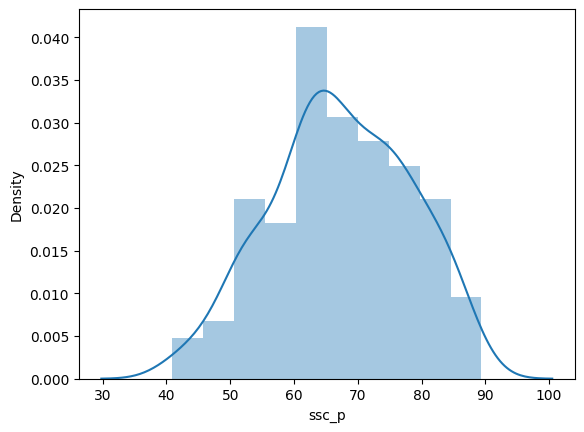

In [6]:
sns.distplot(dataset["ssc_p"],kde=True)

# Probablity Density Function

In [7]:
def get_Pdf_Probablity(dataset,startrange,endrange):
    from matplotlib import pyplot
    from scipy.stats import norm 
    import seaborn as sns
    ax = sns.distplot(dataset,kde=True,kde_kws={"color":"Blue"},color="Green")

    pyplot.axvline(startrange,color="Red")
    pyplot.axvline(endrange,color="Red")

    # Calculate the parameters
    sample = dataset
    sample_mean = sample.mean()
    sample_std = sample.std()
    print(f"mean={sample_mean:.3f}, standard deviation= :{sample_std:.3f}")
    # Normal distribution 
    dist = norm(sample_mean,sample_std)

    # Probablity distribution function
    values = [value for value in range(startrange,endrange)]
    probablity = [dist.pdf(value)for value in values]
    prob = sum(probablity)
    print(f"The area between range({startrange},{endrange}):{prob:.3f}")
    return prob

mean=67.303, standard deviation= :10.827
The area between range(50,80):0.820


C:\Users\thiru\AppData\Local\Temp\ipykernel_17544\458449511.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax = sns.distplot(dataset,kde=True,kde_kws={"color":"Blue"},color="Green")


np.float64(0.8201083468562449)

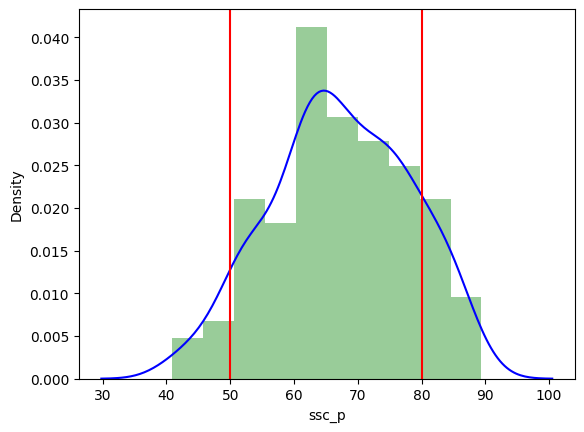

In [8]:
get_Pdf_Probablity(dataset["ssc_p"],50,80)

# Same function without using List comprehension

In [9]:
def get_Pdf_Probablity(dataset,startrange,endrange):
    from matplotlib import pyplot
    from scipy.stats import norm 
    import seaborn as sns
    ax = sns.distplot(dataset,kde=True,kde_kws={"color":"Blue"},color="Green")

    pyplot.axvline(startrange,color="Red")
    pyplot.axvline(endrange,color="Red")

    # Calculate the parameters
    sample = dataset
    sample_mean = sample.mean()
    sample_std = sample.std()
    print(f"mean={sample_mean:.3f}, standard deviation= :{sample_std:.3f}")
    # Normal distribution 
    dist = norm(sample_mean,sample_std)

    # Probablity distribution function
    values = []
    for value in range(startrange,endrange):
        values.append(value)

    probablity = []
    for value in values:
        pdf = dist.pdf(value)
        probablity.append(pdf)
    prob = sum(probablity)
    print(f"The area between range({startrange},{endrange}):{prob:.3f}")
    return prob

C:\Users\thiru\AppData\Local\Temp\ipykernel_17544\2314696573.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax = sns.distplot(dataset,kde=True,kde_kws={"color":"Blue"},color="Green")


mean=67.303, standard deviation= :10.827
The area between range(50,80):0.820


np.float64(0.8201083468562449)

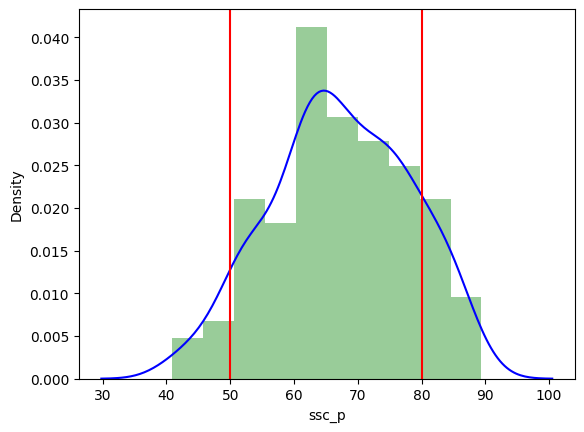

In [10]:
get_Pdf_Probablity(dataset["ssc_p"],50,80)

# Cumulative Density Function

In [11]:
from statsmodels.distributions.empirical_distribution import ECDF
ecdf = ECDF(dataset["ssc_p"])
ecdf(56)

np.float64(0.17209302325581394)